# Precision hold

A servo holding one angle against a load step, the shaft watched through it.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


In [3]:
import time

drive = device.drive
drive.source('model')
drive.model_param(j=2e-5, b=1e-5, load=0.0)
device.gates.arm(bypass_sto=True, ignore_interlock=True)

def watch_shaft(seconds, every=0.02):
    rows = []
    t0 = time.monotonic()
    while time.monotonic() - t0 < seconds:
        rows.append((time.monotonic() - t0, device.angle.state()['degrees']))
        time.sleep(every)
    return rows

Hold at 30 degrees. A load step on the model pulls the shaft off the command by the spring's sag; the next correction takes it back.

In [4]:
with device.motion.servo(amps=3.0, settle=0.3) as hold:
    zero = hold.to(30.0, tol=0.25)
    print('held at %.2f deg, error %.2f' % (zero, hold.error))
    before = watch_shaft(0.5)
    drive.model_param(load=0.03)
    during = watch_shaft(0.8)
    corrected = hold.to(30.0, tol=0.25)
    print('after the load step: shaft %.2f deg, error %.2f' % (corrected, hold.error))
    after = watch_shaft(0.5)
    drive.model_param(load=0.0)
device.gates.disarm()
drive.source('adc')

held at 29.97 deg, error 0.03


after the load step: shaft 30.05 deg, error -0.05


True

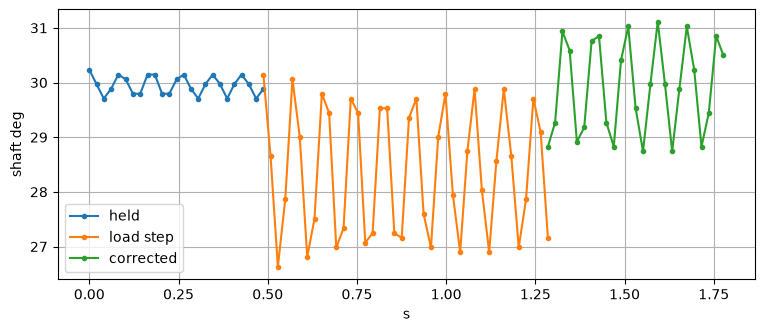

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.5))
t = 0.0
for rows, label in ((before, 'held'), (during, 'load step'), (after, 'corrected')):
    ax.plot([t + r[0] for r in rows], [r[1] for r in rows], '.-', label=label)
    t += rows[-1][0]
ax.set_xlabel('s'); ax.set_ylabel('shaft deg'); ax.legend(); ax.grid(True)
plt.show()
device.close()

## Conclusions

In [6]:
held = sum(r[1] for r in before) / len(before)
pulled = sum(r[1] for r in during[len(during) // 2:]) / (len(during) - len(during) // 2)
back = sum(r[1] for r in after) / len(after)
print('held at          %.2f deg (asked 30.00)' % held)
print('under 0.03 N.m   %.2f deg, sag %.2f deg' % (pulled, pulled - held))
print('after correcting %.2f deg, residual %.2f deg' % (back, back - 30.0))
print('sampled at       %.0f Hz through each phase' % (len(before) / before[-1][0]))
print('holding current  3.0 A, tolerance 0.25 deg')

held at          29.95 deg (asked 30.00)
under 0.03 N.m   28.44 deg, sag -1.51 deg
after correcting 29.91 deg, residual -0.09 deg
sampled at       51 Hz through each phase
holding current  3.0 A, tolerance 0.25 deg


The sag is the load-angle spring at work: HOLD commutates on the **commanded** angle, and the rotor sits wherever `amps kt sin(delta)` balances the load. That angle is the error, and it is a fact about the torque - a stiffer hold is more current, not a tighter loop.

The correction moves the command by the measured error, so the spring is re-centred rather than fought. Nothing here runs a position loop per pass: the ring is at the same frequency the link corrects at, and closing per pass pumps it.

A shaft that stays outside `tol` after `tries` corrections raises with what it saw - the load is past the holding torque, or there is no magnet in front of the sensor.